In [ ]:
from datasets import load_dataset
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import pipeline
import torch
from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.float_format', '{:,.0f}'.format)

Mounted at /content/drive


In [ ]:
%cd "drive/MyDrive/Colab Notebooks/MIS 769/AnalyzeMe2"

/content/drive/MyDrive/Colab Notebooks/MIS 769/AnalyzeMe2


In [ ]:
# Load the narrowed top-10 prices file
prices_df = pd.read_parquet("top10_prices_recent.parquet")

# Load the daily aggregated sentiment file
sentiment_df = pd.read_parquet("daily_sentiment_top10.parquet")

# Quick checks
print("Prices DataFrame:")
print("Shape:", prices_df.shape)
print("Columns:", prices_df.columns.tolist())
print("Date range:", prices_df['report_date'].min(), "to", prices_df['report_date'].max())
print("\nFirst 3 rows:")
print(prices_df.head(3))

print("\n" + "="*60 + "\n")

print("Sentiment DataFrame:")
print("Shape:", sentiment_df.shape)
print("Columns:", sentiment_df.columns.tolist())
print("Date range:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())
print("\nFirst 3 rows:")
print(sentiment_df.head(3))

Prices DataFrame:
Shape: (2530, 7)
Columns: ['symbol', 'report_date', 'open', 'close', 'high', 'low', 'volume']
Date range: 2025-03-12 00:00:00 to 2026-03-13 00:00:00

First 3 rows:
  symbol report_date    open   close    high     low    volume
0   AAPL  2025-03-12  220.14  216.98  221.75  214.91  62547500
1   AAPL  2025-03-13  215.95  209.68  216.84  208.42  61368300
2   AAPL  2025-03-14  211.25  213.49  213.95  209.58  60107600


Sentiment DataFrame:
Shape: (2959, 5)
Columns: ['ticker', 'date', 'finbert_mean', 'vader_mean', 'article_count']
Date range: 2025-03-12 to 2026-03-15

First 3 rows:
  ticker        date  finbert_mean  vader_mean  article_count
0   AAPL  2025-03-21             1           1              3
1   AAPL  2025-03-22             1           1              1
2   AAPL  2025-04-02            -1           1              1


In [ ]:
# Ensure report_date is datetime
prices_df['report_date'] = pd.to_datetime(prices_df['report_date'])

# Sort by ticker and date for correct shift
prices_df = prices_df.sort_values(['symbol', 'report_date'])

# 1. Intraday return: open to close (same day)
prices_df['intraday_return'] = (prices_df['close'] - prices_df['open']) / prices_df['open']

# 2. Daily return: close to next close (previous day's close)
prices_df['daily_return'] = prices_df.groupby('symbol')['close'].pct_change()

# Quick checks
print("New columns added:")
print(prices_df[['symbol', 'report_date', 'open', 'close', 'intraday_return', 'daily_return']].head(10))

print("\nSummary stats for returns:")
print(prices_df[['intraday_return', 'daily_return']].describe())

# Optional: save updated prices with returns
prices_df.to_parquet("top10_prices_with_returns.parquet", index=False)
print("Saved to top10_prices_with_returns.parquet")

New columns added:
  symbol report_date    open   close                    intraday_return  \
0   AAPL  2025-03-12  220.14  216.98   -0.01435450168074861451803397838   
1   AAPL  2025-03-13  215.95  209.68   -0.02903449872655707339661958787   
2   AAPL  2025-03-14  211.25  213.49    0.01060355029585798816568047337   
3   AAPL  2025-03-17  213.31  214.00   0.003234728798462331817542543716   
4   AAPL  2025-03-18  214.16  212.69  -0.006864026895778856929398580501   
5   AAPL  2025-03-19  214.22  215.24   0.004761460181122210811315470077   
6   AAPL  2025-03-20  213.99  214.10  0.0005140427122762745922706668536   
7   AAPL  2025-03-21  211.56  218.27    0.03171677065607865380979391189   
8   AAPL  2025-03-24  221.00  220.73  -0.001221719457013574660633484163   
9   AAPL  2025-03-25  220.77  223.75    0.01349821080762784798659238121   

                      daily_return  
0                              NaN  
1  -0.0336436537929763111807539865  
2    0.018170545593285005723006486  
3    0.

In [ ]:
# Round both return columns to 3 decimal places
prices_df['intraday_return'] = prices_df['intraday_return'].round(3)
prices_df['daily_return'] = prices_df['daily_return'].round(3)

# Quick check on the same sample rows
print("Updated returns with 3 decimal places:")
print(prices_df[['symbol', 'report_date', 'intraday_return', 'daily_return']].head(10))

# Optional: save again with rounded values
prices_df.to_parquet("top10_prices_with_returns.parquet", index=False)
print("Saved rounded version to top10_prices_with_returns.parquet")

Updated returns with 3 decimal places:
  symbol report_date                    intraday_return  \
0   AAPL  2025-03-12   -0.01435450168074861451803397838   
1   AAPL  2025-03-13   -0.02903449872655707339661958787   
2   AAPL  2025-03-14    0.01060355029585798816568047337   
3   AAPL  2025-03-17   0.003234728798462331817542543716   
4   AAPL  2025-03-18  -0.006864026895778856929398580501   
5   AAPL  2025-03-19   0.004761460181122210811315470077   
6   AAPL  2025-03-20  0.0005140427122762745922706668536   
7   AAPL  2025-03-21    0.03171677065607865380979391189   
8   AAPL  2025-03-24  -0.001221719457013574660633484163   
9   AAPL  2025-03-25    0.01349821080762784798659238121   

                      daily_return  
0                              NaN  
1  -0.0336436537929763111807539865  
2    0.018170545593285005723006486  
3    0.002388870673099442596842943  
4  -0.0061214953271028037383177570  
5    0.011989280173021768771451408  
6  -0.0052964133060769373722356439  
7    0.01947687

In [ ]:
# Option 1: Global setting (affects all floats in this session)
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', '{:.3f}'.format)  # forces 3 decimals

# Then print again
print("Updated returns with 3 decimal places:")
print(prices_df[['symbol', 'report_date', 'intraday_return', 'daily_return']].head(10))

Updated returns with 3 decimal places:
  symbol report_date                    intraday_return  \
0   AAPL  2025-03-12   -0.01435450168074861451803397838   
1   AAPL  2025-03-13   -0.02903449872655707339661958787   
2   AAPL  2025-03-14    0.01060355029585798816568047337   
3   AAPL  2025-03-17   0.003234728798462331817542543716   
4   AAPL  2025-03-18  -0.006864026895778856929398580501   
5   AAPL  2025-03-19   0.004761460181122210811315470077   
6   AAPL  2025-03-20  0.0005140427122762745922706668536   
7   AAPL  2025-03-21    0.03171677065607865380979391189   
8   AAPL  2025-03-24  -0.001221719457013574660633484163   
9   AAPL  2025-03-25    0.01349821080762784798659238121   

                      daily_return  
0                              NaN  
1  -0.0336436537929763111807539865  
2    0.018170545593285005723006486  
3    0.002388870673099442596842943  
4  -0.0061214953271028037383177570  
5    0.011989280173021768771451408  
6  -0.0052964133060769373722356439  
7    0.01947687

In [ ]:
print("Updated returns with 3 decimal places:")
print(
    prices_df[['symbol', 'report_date', 'intraday_return', 'daily_return']]
    .head(10)
    .to_string(float_format='{:,.3f}'.format)
)

Updated returns with 3 decimal places:
  symbol report_date                    intraday_return                     daily_return
0   AAPL  2025-03-12   -0.01435450168074861451803397838                              NaN
1   AAPL  2025-03-13   -0.02903449872655707339661958787  -0.0336436537929763111807539865
2   AAPL  2025-03-14    0.01060355029585798816568047337    0.018170545593285005723006486
3   AAPL  2025-03-17   0.003234728798462331817542543716    0.002388870673099442596842943
4   AAPL  2025-03-18  -0.006864026895778856929398580501  -0.0061214953271028037383177570
5   AAPL  2025-03-19   0.004761460181122210811315470077    0.011989280173021768771451408
6   AAPL  2025-03-20  0.0005140427122762745922706668536  -0.0052964133060769373722356439
7   AAPL  2025-03-21    0.03171677065607865380979391189    0.019476879962634283045305932
8   AAPL  2025-03-24  -0.001221719457013574660633484163    0.011270444861868328217345490
9   AAPL  2025-03-25    0.01349821080762784798659238121    0.0136818737

In [ ]:
# Show exact stored values (bypasses display formatting)
print("Exact stored intraday_return values (first 10):")
for val in prices_df['intraday_return'].head(10):
    print(f"{val:.3f}")

print("\nExact stored daily_return values (first 10):")
for val in prices_df['daily_return'].head(10):
    print(f"{val:.3f}" if not pd.isna(val) else "NaN")

Exact stored intraday_return values (first 10):
-0.014
-0.029
0.011
0.003
-0.007
0.005
0.001
0.032
-0.001
0.013

Exact stored daily_return values (first 10):
NaN
-0.034
0.018
0.002
-0.006
0.012
-0.005
0.019
0.011
0.014


In [ ]:
# Force 3 decimal places for all float columns in display
pd.set_option('display.precision', 3)
pd.set_option('display.float_format', '{:.3f}'.format)

In [ ]:
print(prices_df[['symbol', 'report_date', 'intraday_return', 'daily_return']].head(10).to_string(float_format='{:,.3f}'.format))

  symbol report_date                    intraday_return                     daily_return
0   AAPL  2025-03-12   -0.01435450168074861451803397838                              NaN
1   AAPL  2025-03-13   -0.02903449872655707339661958787  -0.0336436537929763111807539865
2   AAPL  2025-03-14    0.01060355029585798816568047337    0.018170545593285005723006486
3   AAPL  2025-03-17   0.003234728798462331817542543716    0.002388870673099442596842943
4   AAPL  2025-03-18  -0.006864026895778856929398580501  -0.0061214953271028037383177570
5   AAPL  2025-03-19   0.004761460181122210811315470077    0.011989280173021768771451408
6   AAPL  2025-03-20  0.0005140427122762745922706668536  -0.0052964133060769373722356439
7   AAPL  2025-03-21    0.03171677065607865380979391189    0.019476879962634283045305932
8   AAPL  2025-03-24  -0.001221719457013574660633484163    0.011270444861868328217345490
9   AAPL  2025-03-25    0.01349821080762784798659238121    0.013681873782449146015494042


In [ ]:
# One-time formatted print without changing global settings
from pandas.io.formats.style import Styler

styled = prices_df[['symbol', 'report_date', 'intraday_return', 'daily_return']].head(10).style.format({
    'intraday_return': '{:.3f}',
    'daily_return': '{:.3f}'
})

display(styled)

,symbol,report_date,intraday_return,daily_return
0,AAPL,2025-03-12 00:00:00,-0.014,nan
1,AAPL,2025-03-13 00:00:00,-0.029,-0.034
2,AAPL,2025-03-14 00:00:00,0.011,0.018
3,AAPL,2025-03-17 00:00:00,0.003,0.002
4,AAPL,2025-03-18 00:00:00,-0.007,-0.006
5,AAPL,2025-03-19 00:00:00,0.005,0.012
6,AAPL,2025-03-20 00:00:00,0.001,-0.005
7,AAPL,2025-03-21 00:00:00,0.032,0.019
8,AAPL,2025-03-24 00:00:00,-0.001,0.011
9,AAPL,2025-03-25 00:00:00,0.013,0.014


In [ ]:
# 1. Ticker compatibility
print("Unique tickers in sentiment_df:", sorted(sentiment_df['ticker'].unique()))
print("Unique symbols in prices_df:", sorted(prices_df['symbol'].unique()))

# Check if sets match
sentiment_tickers = set(sentiment_df['ticker'])
prices_symbols = set(prices_df['symbol'])
print("\nTickers in sentiment but not prices:", sentiment_tickers - prices_symbols)
print("Symbols in prices but not sentiment:", prices_symbols - sentiment_tickers)

# Types
print("\nTicker type:", sentiment_df['ticker'].dtype)
print("Symbol type:", prices_df['symbol'].dtype)

Unique tickers in sentiment_df: ['AAPL', 'AMZN', 'FDS', 'GOOG', 'INTC', 'META', 'MSFT', 'NVDA', 'PLTR', 'TSLA']
Unique symbols in prices_df: ['AAPL', 'AMZN', 'FDS', 'GOOG', 'INTC', 'META', 'MSFT', 'NVDA', 'PLTR', 'TSLA']

Tickers in sentiment but not prices: set()
Symbols in prices but not sentiment: set()

Ticker type: object
Symbol type: object


In [ ]:
# 2. Date compatibility
print("\nDate type in sentiment_df:", sentiment_df['date'].dtype)
print("Report_date type in prices_df:", prices_df['report_date'].dtype)

# Sample dates
print("\nSample dates from sentiment_df:", sentiment_df['date'].head().tolist())
print("Sample dates from prices_df:", prices_df['report_date'].head().dt.date.tolist())  # .dt.date to strip time

# Min/max to compare ranges
print("\nSentiment date range:", sentiment_df['date'].min(), "to", sentiment_df['date'].max())
print("Prices date range:", prices_df['report_date'].dt.date.min(), "to", prices_df['report_date'].dt.date.max())


Date type in sentiment_df: object
Report_date type in prices_df: datetime64[ns]

Sample dates from sentiment_df: [datetime.date(2025, 3, 21), datetime.date(2025, 3, 22), datetime.date(2025, 4, 2), datetime.date(2025, 4, 3), datetime.date(2025, 4, 8)]
Sample dates from prices_df: [datetime.date(2025, 3, 12), datetime.date(2025, 3, 13), datetime.date(2025, 3, 14), datetime.date(2025, 3, 17), datetime.date(2025, 3, 18)]

Sentiment date range: 2025-03-12 to 2026-03-15
Prices date range: 2025-03-12 to 2026-03-13


In [ ]:
# Rename symbol to ticker for consistency
prices_df = prices_df.rename(columns={'symbol': 'ticker'})

# Create date column from report_date (date only, no time)
prices_df['date'] = pd.to_datetime(prices_df['report_date']).dt.date

# Merge: inner join on ticker + date
merged_df = pd.merge(
    sentiment_df,          # or sentiment_df if you prefer the aggregated version
    prices_df,
    on=['ticker', 'date'],
    how='inner'
)

# Sort by ticker and date for time-series order
merged_df = merged_df.sort_values(['ticker', 'date'])

# Quick checks
print("Merged DataFrame shape:", merged_df.shape)
print("\nColumns:", merged_df.columns.tolist())
print("\nDate range:", merged_df['date'].min(), "to", merged_df['date'].max())
print("\nUnique tickers:", sorted(merged_df['ticker'].unique()))
print("\nFirst 5 rows:")
print(merged_df.head())

# Save the merged result
merged_df.to_parquet("merged_sentiment_prices.parquet", index=False)
print("Saved to merged_sentiment_prices.parquet")

Merged DataFrame shape: (2141, 13)

Columns: ['ticker', 'date', 'finbert_mean', 'vader_mean', 'article_count', 'report_date', 'open', 'close', 'high', 'low', 'volume', 'intraday_return', 'daily_return']

Date range: 2025-03-12 to 2026-03-13

Unique tickers: ['AAPL', 'AMZN', 'FDS', 'GOOG', 'INTC', 'META', 'MSFT', 'NVDA', 'PLTR', 'TSLA']

First 5 rows:
  ticker        date  finbert_mean  vader_mean  article_count report_date  \
0   AAPL  2025-03-21         0.783       0.998              3  2025-03-21   
1   AAPL  2025-04-02        -0.842       0.989              1  2025-04-02   
2   AAPL  2025-04-03        -0.739      -0.612              1  2025-04-03   
3   AAPL  2025-04-08        -0.474       0.998              1  2025-04-08   
4   AAPL  2025-04-09         0.000       0.998              1  2025-04-09   

     open   close    high     low     volume  \
0  211.56  218.27  218.84  211.28   94127800   
1  221.32  223.89  225.19  221.02   35905900   
2  205.54  203.19  207.49  201.25  10341

In [ ]:
# Sort by ticker and date (should already be sorted, but safe)
merged_df = merged_df.sort_values(['ticker', 'date'])

# Compute next-day return: shift daily_return forward by 1 per ticker
merged_df['next_day_return'] = merged_df.groupby('ticker')['daily_return'].shift(-1)

# Quick check
print("Added next_day_return - sample with it:")
print(merged_df[['ticker', 'date', 'daily_return', 'next_day_return']].head(15))

print("\nNext_day_return stats:")
print(merged_df['next_day_return'].describe())

# Last row per ticker will be NaN (no tomorrow) - normal
print("\nNumber of NaN in next_day_return:", merged_df['next_day_return'].isna().sum())

# Optional: save updated merged df
merged_df.to_parquet("merged_with_next_day.parquet", index=False)
print("Saved to merged_with_next_day.parquet")

Added next_day_return - sample with it:
   ticker        date                     daily_return  \
0    AAPL  2025-03-21    0.019476879962634283045305932   
1    AAPL  2025-04-02    0.003136341233926251176127963   
2    AAPL  2025-04-03  -0.0924561168430925901112153290   
3    AAPL  2025-04-08  -0.0498181417392262757632536096   
4    AAPL  2025-04-09    0.153288481614661872172601786   
5    AAPL  2025-04-14    0.022053999495331819328791320   
6    AAPL  2025-05-01    0.003858823529411764705882353   
7    AAPL  2025-05-07  -0.0113848168857992040703239132   
8    AAPL  2025-05-08    0.006318471337579617834394904   
9    AAPL  2025-05-09    0.005266089422249227809002987   
10   AAPL  2025-05-12    0.061753891099581927164660253   
11   AAPL  2025-05-13    0.010152284263959390862944162   
12   AAPL  2025-05-14  -0.0028178274550321701967782839   
13   AAPL  2025-05-15  -0.0041444920642396269957142184   
14   AAPL  2025-05-16  -0.0008985575786237881295814613   

                    next_day_re

In [ ]:
# 1. Overall correlations (Pearson)
print("=== Overall Pearson Correlation ===")
print("With daily_return:")
print(merged_df[['finbert_mean', 'vader_mean', 'daily_return']].corr()['daily_return'])

print("\nWith next_day_return:")
print(merged_df[['finbert_mean', 'vader_mean', 'next_day_return']].corr()['next_day_return'])

# 2. Spearman correlations (rank-based, robust to outliers)
print("\n=== Spearman Correlation (rank-based) ===")
print("With next_day_return:")
print(merged_df[['finbert_mean', 'vader_mean', 'next_day_return']].corr(method='spearman')['next_day_return'])

# 3. Per-ticker correlation with next_day_return
print("\n=== Per-ticker Pearson Correlation with next_day_return ===")
finbert_per_ticker = merged_df.groupby('ticker')['finbert_mean'].corr(merged_df['next_day_return'])
print("FinBERT vs next_day_return:")
print(finbert_per_ticker.sort_values(ascending=False))

print("\nVADER vs next_day_return:")
vader_per_ticker = merged_df.groupby('ticker')['vader_mean'].corr(merged_df['next_day_return'])
print(vader_per_ticker.sort_values(ascending=False))

# 4. Sample sizes per ticker (context for correlation reliability)
print("\n=== Number of days per ticker ===")
print(merged_df.groupby('ticker').size().sort_values(ascending=False))

# Optional: drop rows with NaN in next_day_return for clean stats
clean_df = merged_df.dropna(subset=['next_day_return'])
print(f"\nClean rows (with next_day_return): {len(clean_df)}")

=== Overall Pearson Correlation ===
With daily_return:
finbert_mean   0.056
vader_mean     0.052
daily_return   1.000
Name: daily_return, dtype: float64

With next_day_return:
finbert_mean      -0.010
vader_mean        -0.003
next_day_return    1.000
Name: next_day_return, dtype: float64

=== Spearman Correlation (rank-based) ===
With next_day_return:
finbert_mean      -0.034
vader_mean        -0.043
next_day_return    1.000
Name: next_day_return, dtype: float64

=== Per-ticker Pearson Correlation with next_day_return ===
FinBERT vs next_day_return:
ticker
AMZN    0.190
INTC    0.042
AAPL    0.009
MSFT   -0.012
PLTR   -0.016
FDS    -0.016
TSLA   -0.037
META   -0.066
GOOG   -0.069
NVDA   -0.074
Name: finbert_mean, dtype: float64

VADER vs next_day_return:
ticker
NVDA    0.104
AMZN    0.049
INTC    0.038
META    0.021
GOOG   -0.009
MSFT   -0.025
AAPL   -0.042
FDS    -0.056
TSLA   -0.097
PLTR   -0.145
Name: vader_mean, dtype: float64

=== Number of days per ticker ===
ticker
NVDA    233
A

In [ ]:
# Convert to numeric, forcing errors to NaN if any bad values
merged_df['intraday_return'] = pd.to_numeric(merged_df['intraday_return'], errors='coerce')
merged_df['daily_return']   = pd.to_numeric(merged_df['daily_return'],   errors='coerce')

# Optional: fill any new NaNs if you want (or leave as is)
# merged_df['intraday_return'] = merged_df['intraday_return'].fillna(0)

# Verify dtypes
print("Updated dtypes:")
print(merged_df[['intraday_return', 'daily_return']].dtypes)

# Now re-run your top 5 code — it should work
print("\nTop 5 most positive intraday_return days:")
print(merged_df.nlargest(5, 'intraday_return')[['ticker', 'date', 'intraday_return', 'finbert_mean']])

print("\nTop 5 most negative intraday_return days:")
print(merged_df.nsmallest(5, 'intraday_return')[['ticker', 'date', 'intraday_return', 'finbert_mean']])

Updated dtypes:
intraday_return    float64
daily_return       float64
dtype: object

Top 5 most positive intraday_return days:
     ticker        date  intraday_return  finbert_mean
833    INTC  2025-04-09            0.191        -0.554
4      AAPL  2025-04-09            0.156         0.000
1484   NVDA  2025-04-09            0.156         0.868
1924   TSLA  2025-04-02            0.111        -0.906
993    INTC  2026-01-09            0.089        -0.005

Top 5 most negative intraday_return days:
     ticker        date  intraday_return  finbert_mean
1949   TSLA  2025-06-05           -0.117        -0.281
504     FDS  2025-09-18           -0.110        -0.937
1891   PLTR  2026-02-04           -0.102        -0.109
1740   PLTR  2025-06-27           -0.098         0.494
559     FDS  2025-12-18           -0.097         0.227


In [ ]:
# Drop rows with NaN in returns (to avoid errors in corr)
clean_df = merged_df.dropna(subset=['intraday_return', 'daily_return'])

# 1. Overall Pearson correlation with intraday_return
print("=== Overall Pearson Correlation with intraday_return ===")
print(clean_df[['finbert_mean', 'vader_mean', 'intraday_return']].corr()['intraday_return'].round(4))

# 2. Spearman correlation with intraday_return
print("\n=== Spearman Correlation with intraday_return ===")
print(clean_df[['finbert_mean', 'vader_mean', 'intraday_return']].corr(method='spearman')['intraday_return'].round(4))

# 3. Per-ticker Pearson correlation with intraday_return
print("\n=== Per-ticker Pearson Correlation with intraday_return ===")
finbert_intraday = clean_df.groupby('ticker')['finbert_mean'].corr(clean_df['intraday_return'])
print("FinBERT vs intraday_return:")
print(finbert_intraday.sort_values(ascending=False).round(4))

print("\nVADER vs intraday_return:")
vader_intraday = clean_df.groupby('ticker')['vader_mean'].corr(clean_df['intraday_return'])
print(vader_intraday.sort_values(ascending=False).round(4))

# 4. Per-ticker Pearson correlation with daily_return (for comparison)
print("\n=== Per-ticker Pearson Correlation with daily_return ===")
finbert_daily = clean_df.groupby('ticker')['finbert_mean'].corr(clean_df['daily_return'])
print("FinBERT vs daily_return:")
print(finbert_daily.sort_values(ascending=False).round(4))

print("\nVADER vs daily_return:")
vader_daily = clean_df.groupby('ticker')['vader_mean'].corr(clean_df['daily_return'])
print(vader_daily.sort_values(ascending=False).round(4))

# Sample sizes (for context)
print("\n=== Number of days per ticker (after dropna) ===")
print(clean_df.groupby('ticker').size().sort_values(ascending=False))

=== Overall Pearson Correlation with intraday_return ===
finbert_mean      0.002
vader_mean        0.025
intraday_return   1.000
Name: intraday_return, dtype: float64

=== Spearman Correlation with intraday_return ===
finbert_mean      0.008
vader_mean        0.010
intraday_return   1.000
Name: intraday_return, dtype: float64

=== Per-ticker Pearson Correlation with intraday_return ===
FinBERT vs intraday_return:
ticker
FDS     0.137
NVDA    0.089
META    0.086
PLTR    0.049
AAPL    0.017
MSFT    0.010
GOOG    0.010
AMZN   -0.031
INTC   -0.044
TSLA   -0.115
Name: finbert_mean, dtype: float64

VADER vs intraday_return:
ticker
PLTR    0.099
META    0.096
INTC    0.070
MSFT    0.059
AAPL    0.024
AMZN    0.004
NVDA   -0.004
TSLA   -0.032
FDS    -0.056
GOOG   -0.097
Name: vader_mean, dtype: float64

=== Per-ticker Pearson Correlation with daily_return ===
FinBERT vs daily_return:
ticker
AMZN    0.141
FDS     0.139
NVDA    0.138
PLTR    0.126
AAPL    0.100
META    0.059
MSFT    0.020
INTC  

In [ ]:
# Minimum and maximum dates in merged_df
min_date = merged_df['date'].min()
max_date = merged_df['date'].max()

print(f"Minimum date in merged_df: {min_date}")
print(f"Maximum date in merged_df: {max_date}")

# Optional: also show the data types just to confirm
print("\nDate column dtype:", merged_df['date'].dtype)

Minimum date in merged_df: 2025-03-12
Maximum date in merged_df: 2026-03-13

Date column dtype: object


In [ ]:
# 1. Get the unique sorted dates across ALL tickers in the merged df
unique_dates = sorted(merged_df['date'].unique())

# 2. Create a mapping from date → position (1-based)
date_to_x = {date: i + 1 for i, date in enumerate(unique_dates)}

# 3. Add the column to merged_df
merged_df['x_axis_value'] = merged_df['date'].map(date_to_x)

# Quick verification
print("x_axis_value range:", merged_df['x_axis_value'].min(), "to", merged_df['x_axis_value'].max())
print("Number of unique dates:", len(unique_dates))
print("\nSample rows with x_axis_value:")
print(merged_df[['ticker', 'date', 'x_axis_value']].head(10))

# Optional: save the updated merged df
merged_df.to_parquet("merged_with_x_axis.parquet", index=False)
print("Saved to merged_with_x_axis.parquet")

x_axis_value range: 1 to 248
Number of unique dates: 248

Sample rows with x_axis_value:
  ticker        date  x_axis_value
0   AAPL  2025-03-21             7
1   AAPL  2025-04-02            13
2   AAPL  2025-04-03            14
3   AAPL  2025-04-08            16
4   AAPL  2025-04-09            17
5   AAPL  2025-04-14            19
6   AAPL  2025-05-01            31
7   AAPL  2025-05-07            35
8   AAPL  2025-05-08            36
9   AAPL  2025-05-09            37
Saved to merged_with_x_axis.parquet


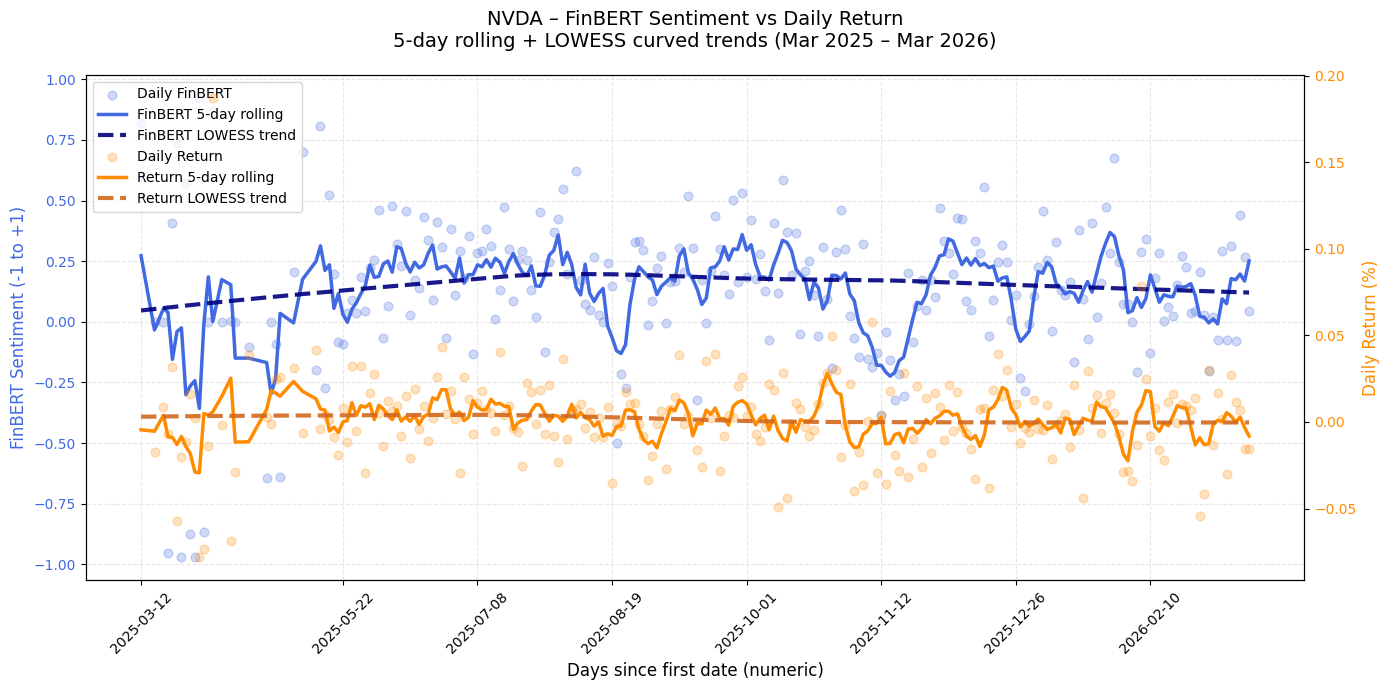

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filter to NVDA only
nvda_df = merged_df[merged_df['ticker'] == 'NVDA'].copy()

# Sort by x_axis_value (already chronological)
nvda_df = nvda_df.sort_values('x_axis_value').reset_index(drop=True)

# Smoothing (5-day rolling mean)
rolling_window = 5
nvda_df['finbert_smoothed'] = nvda_df['finbert_mean'].rolling(
    window=rolling_window, min_periods=1, center=True
).mean()

nvda_df['daily_return_smoothed'] = nvda_df['daily_return'].rolling(
    window=rolling_window, min_periods=1, center=True
).mean()

# Plot using x_axis_value
fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: FinBERT
ax1.scatter(
    nvda_df['x_axis_value'], nvda_df['finbert_mean'],
    color='royalblue', alpha=0.25, s=40, label='Daily FinBERT'
)

ax1.plot(
    nvda_df['x_axis_value'], nvda_df['finbert_smoothed'],
    color='royalblue', linewidth=2.5, label='FinBERT 5-day rolling'
)

# LOWESS curved trend
sns.regplot(
    x=nvda_df['x_axis_value'],
    y=nvda_df['finbert_smoothed'],
    scatter=False,
    lowess=True,
    color='navy',
    line_kws={'linewidth': 3, 'linestyle': '--', 'alpha': 0.9},
    ax=ax1,
    label='FinBERT LOWESS trend'
)

ax1.set_xlabel('Days since first date (numeric)', fontsize=12)
ax1.set_ylabel('FinBERT Sentiment (-1 to +1)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, alpha=0.3, linestyle='--')

# Right axis: Daily return
ax2 = ax1.twinx()

ax2.scatter(
    nvda_df['x_axis_value'], nvda_df['daily_return'],
    color='darkorange', alpha=0.25, s=40, label='Daily Return'
)

ax2.plot(
    nvda_df['x_axis_value'], nvda_df['daily_return_smoothed'],
    color='darkorange', linewidth=2.5, label='Return 5-day rolling'
)

sns.regplot(
    x=nvda_df['x_axis_value'],
    y=nvda_df['daily_return_smoothed'],
    scatter=False,
    lowess=True,
    color='chocolate',
    line_kws={'linewidth': 3, 'linestyle': '--', 'alpha': 0.9},
    ax=ax2,
    label='Return LOWESS trend'
)

ax2.set_ylabel('Daily Return (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title & layout
plt.title('NVDA – FinBERT Sentiment vs Daily Return\n5-day rolling + LOWESS curved trends (Mar 2025 – Mar 2026)',
          fontsize=14, pad=20)

# Custom x-ticks with real dates every ~30 days
tick_step = 30
tick_indices = np.arange(0, len(nvda_df), tick_step)
ax1.set_xticks(nvda_df['x_axis_value'].iloc[tick_indices])

# Format dates from the original date column
dates_for_ticks = pd.to_datetime(nvda_df['date'].iloc[tick_indices])
ax1.set_xticklabels(dates_for_ticks.dt.strftime('%Y-%m-%d'), rotation=45)

plt.tight_layout()
plt.show()

# Save
fig.savefig("nvda_sentiment_vs_return_numeric_x_final.png", dpi=300, bbox_inches='tight')

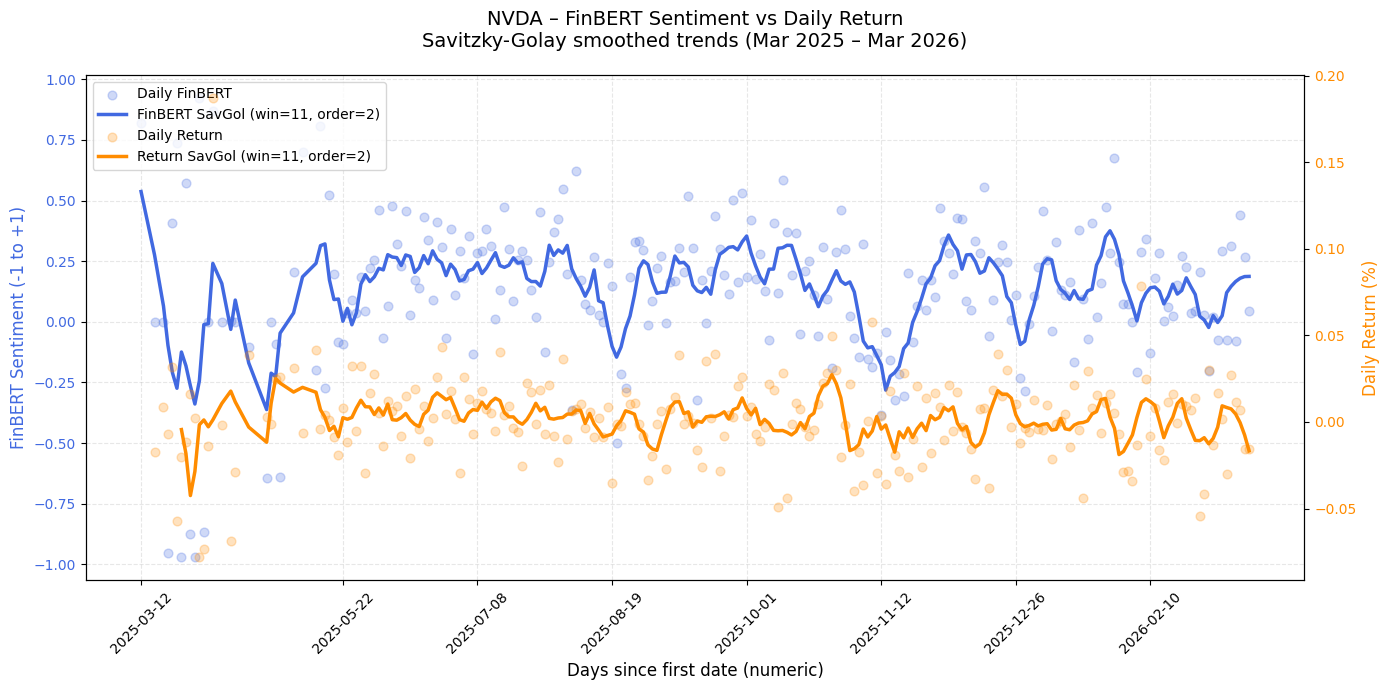

In [ ]:
from scipy.signal import savgol_filter

# Filter to NVDA only
nvda_df = merged_df[merged_df['ticker'] == 'NVDA'].copy()

# Sort by x_axis_value (already chronological)
nvda_df = nvda_df.sort_values('x_axis_value').reset_index(drop=True)

# Savitzky-Golay smoothing only (no rolling or LOWESS)
sg_window = 11      # odd number; tune as needed (7, 11, 15, 21, etc.)
sg_polyorder = 2    # 2 or 3 usually best

nvda_df['finbert_sg'] = savgol_filter(
    nvda_df['finbert_mean'],
    window_length=sg_window,
    polyorder=sg_polyorder,
    mode='interp'
)

nvda_df['daily_return_sg'] = savgol_filter(
    nvda_df['daily_return'],
    window_length=sg_window,
    polyorder=sg_polyorder,
    mode='interp'
)

# Plot using x_axis_value
fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: FinBERT
ax1.scatter(
    nvda_df['x_axis_value'], nvda_df['finbert_mean'],
    color='royalblue', alpha=0.25, s=40, label='Daily FinBERT'
)

ax1.plot(
    nvda_df['x_axis_value'], nvda_df['finbert_sg'],
    color='royalblue', linewidth=2.5, label=f'FinBERT SavGol (win={sg_window}, order={sg_polyorder})'
)

ax1.set_xlabel('Days since first date (numeric)', fontsize=12)
ax1.set_ylabel('FinBERT Sentiment (-1 to +1)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, alpha=0.3, linestyle='--')

# Right axis: Daily return
ax2 = ax1.twinx()

ax2.scatter(
    nvda_df['x_axis_value'], nvda_df['daily_return'],
    color='darkorange', alpha=0.25, s=40, label='Daily Return'
)

ax2.plot(
    nvda_df['x_axis_value'], nvda_df['daily_return_sg'],
    color='darkorange', linewidth=2.5, label=f'Return SavGol (win={sg_window}, order={sg_polyorder})'
)

ax2.set_ylabel('Daily Return (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title & layout
plt.title('NVDA – FinBERT Sentiment vs Daily Return\nSavitzky-Golay smoothed trends (Mar 2025 – Mar 2026)',
          fontsize=14, pad=20)

# Custom x-ticks with real dates every ~30 days
tick_step = 30
tick_indices = np.arange(0, len(nvda_df), tick_step)
ax1.set_xticks(nvda_df['x_axis_value'].iloc[tick_indices])

# Format dates from the original date column
dates_for_ticks = pd.to_datetime(nvda_df['date'].iloc[tick_indices])
ax1.set_xticklabels(dates_for_ticks.dt.strftime('%Y-%m-%d'), rotation=45)

plt.tight_layout()
plt.show()

# Save
fig.savefig("nvda_sentiment_vs_return_savgol_only.png", dpi=300, bbox_inches='tight')

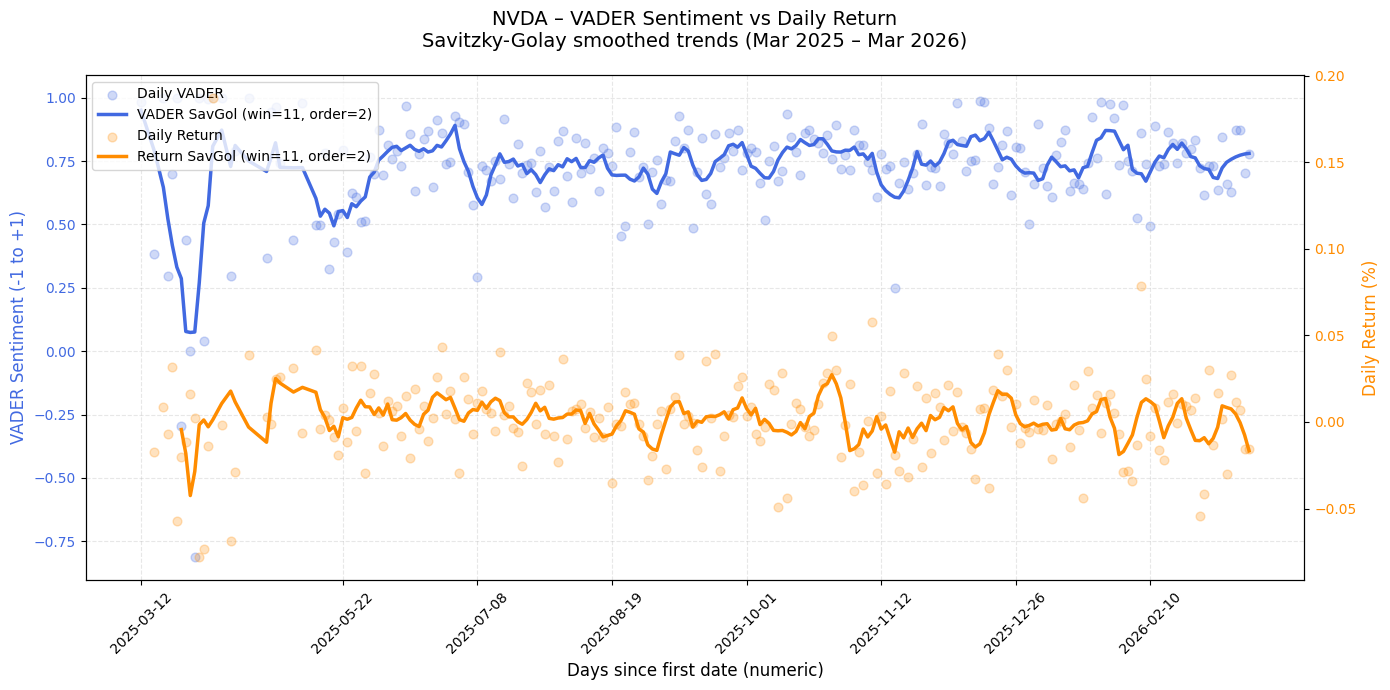

In [ ]:
# Filter to NVDA only
nvda_df = merged_df[merged_df['ticker'] == 'NVDA'].copy()

# Sort by x_axis_value (already chronological)
nvda_df = nvda_df.sort_values('x_axis_value').reset_index(drop=True)

# Savitzky-Golay smoothing (VADER-focused)
sg_window = 11      # tune as needed: 7, 11, 15, 21...
sg_polyorder = 2    # 2 or 3 usually ideal

nvda_df['vader_sg'] = savgol_filter(
    nvda_df['vader_mean'],
    window_length=sg_window,
    polyorder=sg_polyorder,
    mode='interp'
)

nvda_df['daily_return_sg'] = savgol_filter(
    nvda_df['daily_return'],
    window_length=sg_window,
    polyorder=sg_polyorder,
    mode='interp'
)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: VADER only
ax1.scatter(
    nvda_df['x_axis_value'], nvda_df['vader_mean'],
    color='royalblue', alpha=0.25, s=40, label='Daily VADER'
)

ax1.plot(
    nvda_df['x_axis_value'], nvda_df['vader_sg'],
    color='royalblue', linewidth=2.5, label=f'VADER SavGol (win={sg_window}, order={sg_polyorder})'
)

ax1.set_xlabel('Days since first date (numeric)', fontsize=12)
ax1.set_ylabel('VADER Sentiment (-1 to +1)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, alpha=0.3, linestyle='--')

# Right axis: Daily return
ax2 = ax1.twinx()

ax2.scatter(
    nvda_df['x_axis_value'], nvda_df['daily_return'],
    color='darkorange', alpha=0.25, s=40, label='Daily Return'
)

ax2.plot(
    nvda_df['x_axis_value'], nvda_df['daily_return_sg'],
    color='darkorange', linewidth=2.5, label=f'Return SavGol (win={sg_window}, order={sg_polyorder})'
)

ax2.set_ylabel('Daily Return (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title & layout
plt.title('NVDA – VADER Sentiment vs Daily Return\nSavitzky-Golay smoothed trends (Mar 2025 – Mar 2026)',
          fontsize=14, pad=20)

# Custom x-ticks with real dates every ~30 days
tick_step = 30
tick_indices = np.arange(0, len(nvda_df), tick_step)
ax1.set_xticks(nvda_df['x_axis_value'].iloc[tick_indices])

dates_for_ticks = pd.to_datetime(nvda_df['date'].iloc[tick_indices])
ax1.set_xticklabels(dates_for_ticks.dt.strftime('%Y-%m-%d'), rotation=45)

plt.tight_layout()
plt.show()

# Save
fig.savefig("nvda_vader_vs_return_savgol.png", dpi=300, bbox_inches='tight')

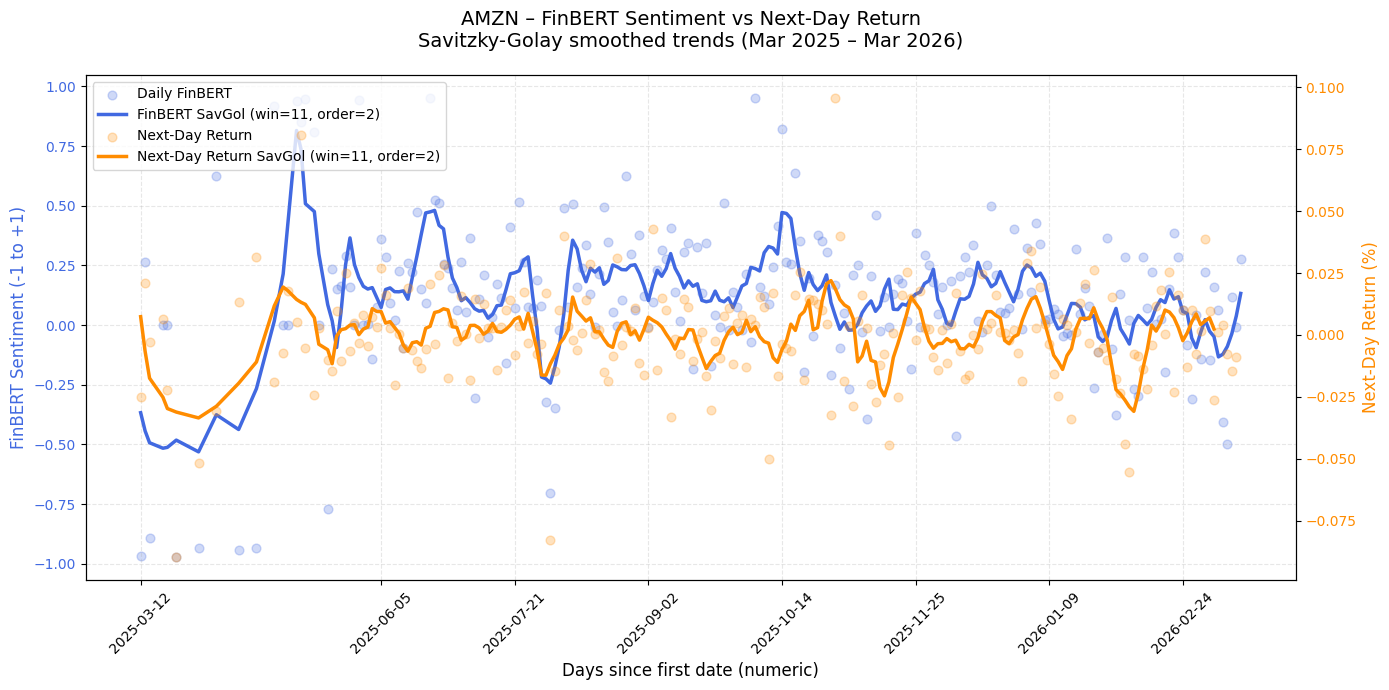

In [ ]:
# Filter to AMZN only
amzn_df = merged_df[merged_df['ticker'] == 'AMZN'].copy()

# Sort by x_axis_value (chronological)
amzn_df = amzn_df.sort_values('x_axis_value').reset_index(drop=True)

# Savitzky-Golay smoothing
sg_window = 11      # tune: 7, 11, 15, 21...
sg_polyorder = 2    # 2 or 3 usually best

amzn_df['finbert_sg'] = savgol_filter(
    amzn_df['finbert_mean'],
    window_length=sg_window,
    polyorder=sg_polyorder,
    mode='interp'
)

amzn_df['next_day_return_sg'] = savgol_filter(
    amzn_df['next_day_return'],
    window_length=sg_window,
    polyorder=sg_polyorder,
    mode='interp'
)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Left axis: FinBERT for AMZN
ax1.scatter(
    amzn_df['x_axis_value'], amzn_df['finbert_mean'],
    color='royalblue', alpha=0.25, s=40, label='Daily FinBERT'
)

ax1.plot(
    amzn_df['x_axis_value'], amzn_df['finbert_sg'],
    color='royalblue', linewidth=2.5, label=f'FinBERT SavGol (win={sg_window}, order={sg_polyorder})'
)

ax1.set_xlabel('Days since first date (numeric)', fontsize=12)
ax1.set_ylabel('FinBERT Sentiment (-1 to +1)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, alpha=0.3, linestyle='--')

# Right axis: Next-day return
ax2 = ax1.twinx()

ax2.scatter(
    amzn_df['x_axis_value'], amzn_df['next_day_return'],
    color='darkorange', alpha=0.25, s=40, label='Next-Day Return'
)

ax2.plot(
    amzn_df['x_axis_value'], amzn_df['next_day_return_sg'],
    color='darkorange', linewidth=2.5, label=f'Next-Day Return SavGol (win={sg_window}, order={sg_polyorder})'
)

ax2.set_ylabel('Next-Day Return (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Title & layout
plt.title('AMZN – FinBERT Sentiment vs Next-Day Return\nSavitzky-Golay smoothed trends (Mar 2025 – Mar 2026)',
          fontsize=14, pad=20)

# Custom x-ticks with real dates every ~30 days
tick_step = 30
tick_indices = np.arange(0, len(amzn_df), tick_step)
ax1.set_xticks(amzn_df['x_axis_value'].iloc[tick_indices])

dates_for_ticks = pd.to_datetime(amzn_df['date'].iloc[tick_indices])
ax1.set_xticklabels(dates_for_ticks.dt.strftime('%Y-%m-%d'), rotation=45)

plt.tight_layout()
plt.show()

# Save
fig.savefig("amzn_finbert_vs_next_day_return_savgol.png", dpi=300, bbox_inches='tight')

/tmp/ipykernel_823/884479438.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


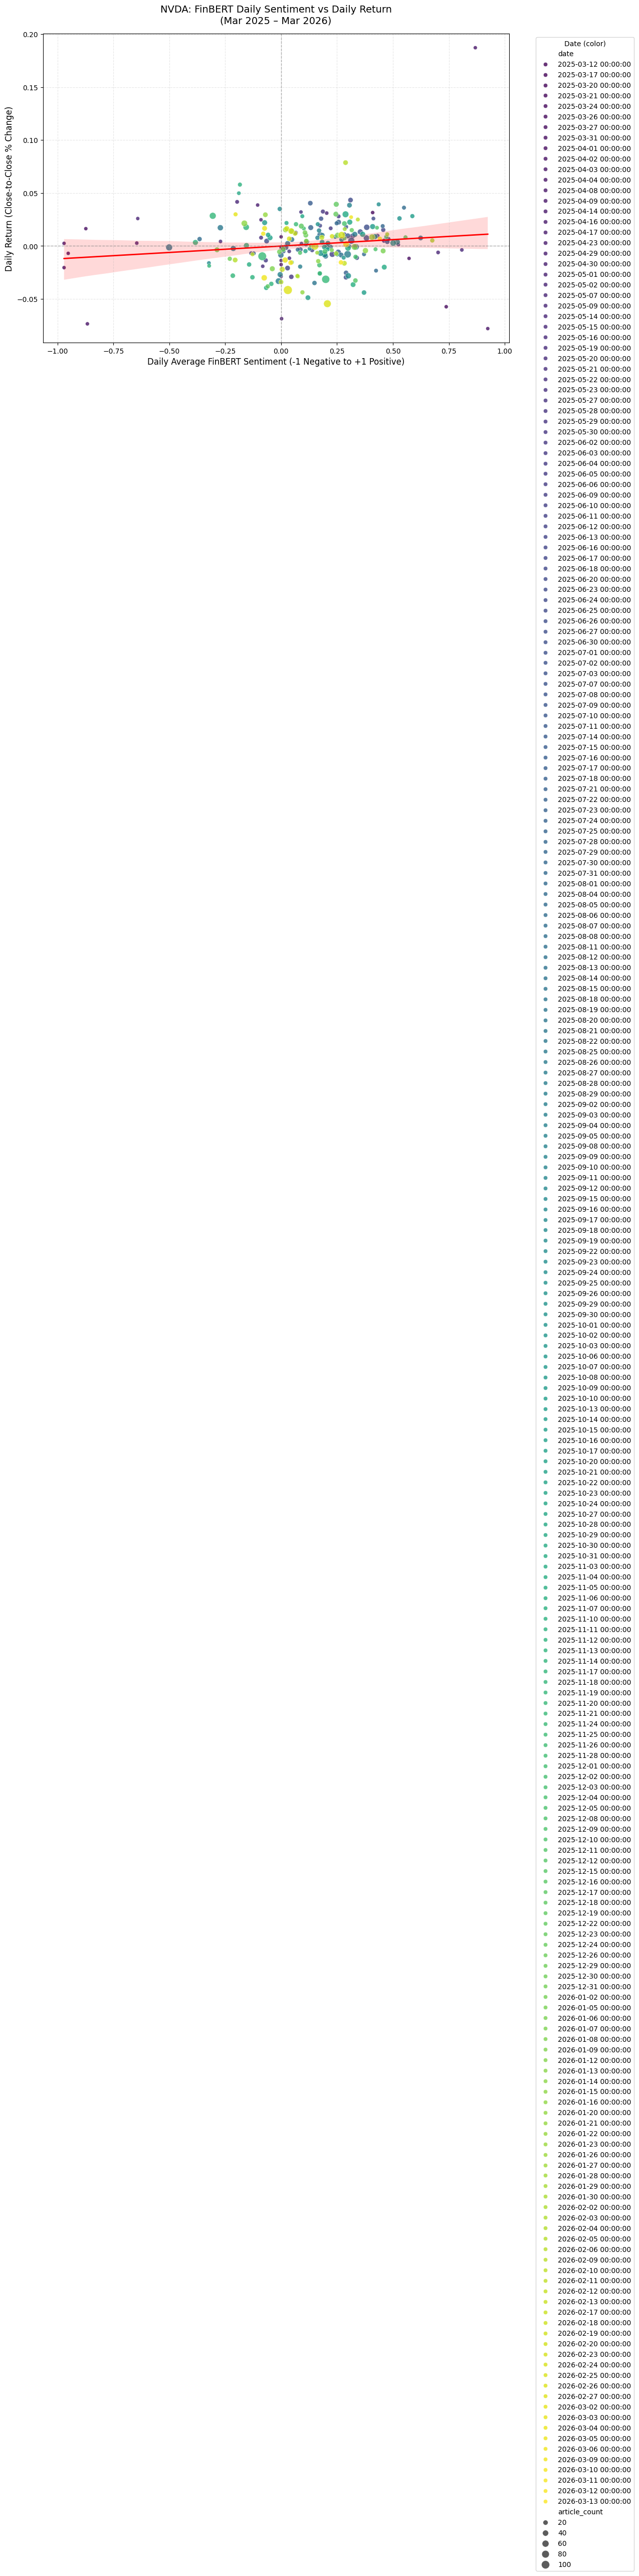

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Filter to NVDA only
nvda_df = merged_df[merged_df['ticker'] == 'NVDA'].copy()

# Ensure date is datetime for coloring
nvda_df['date'] = pd.to_datetime(nvda_df['date'])

# Create figure
plt.figure(figsize=(12, 8))

# Scatter with time-based color gradient
scatter = sns.scatterplot(
    data=nvda_df,
    x='finbert_mean',
    y='daily_return',
    hue='date',
    palette='viridis',          # time gradient: early → dark purple, late → yellow
    size='article_count',       # optional: bigger points for days with more news
    sizes=(30, 150),            # point size range
    alpha=0.8,
    legend='brief'
)

# Add linear regression trend line with confidence interval
sns.regplot(
    data=nvda_df,
    x='finbert_mean',
    y='daily_return',
    scatter=False,               # don't re-draw points
    color='red',
    line_kws={'linewidth': 2, 'label': 'Linear Trend'},
    ci=95                        # 95% confidence interval shading
)

# Formatting
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)

plt.title('NVDA: FinBERT Daily Sentiment vs Daily Return\n(Mar 2025 – Mar 2026)', fontsize=14, pad=15)
plt.xlabel('Daily Average FinBERT Sentiment (-1 Negative to +1 Positive)', fontsize=12)
plt.ylabel('Daily Return (Close-to-Close % Change)', fontsize=12)

plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Date (color)', bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout to fit legend
plt.tight_layout()

plt.show()

# Optional: save high-res
plt.savefig("nvda_finbert_vs_daily_return_scatter_trend.png", dpi=300, bbox_inches='tight')